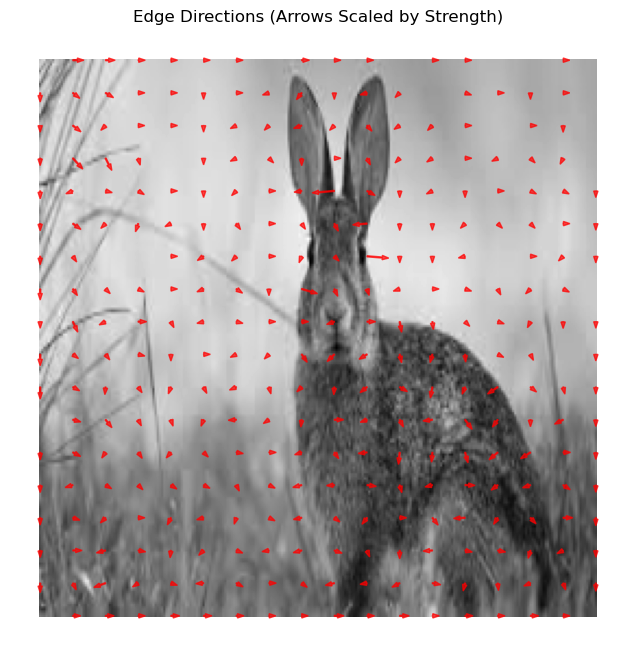

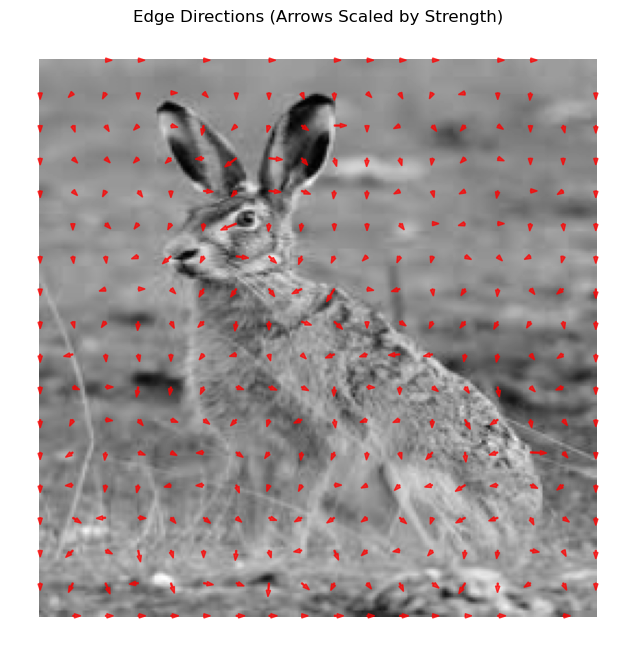

Similarity: 0.44


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def compute_gradients(image):
    # Step 1: Find edges
    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=1)  # Horizontal edges
    gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=1)   # Vertical edges

    magnitude = np.sqrt(gx**2 + gy**2)  # Edge strength
    orientation = np.arctan2(gy, gx) * (180 / np.pi) % 180  # Angle (0° to 180°)

    # Step 2: Normalize magnitude for arrow lengths (NEW)
    norm_magnitude = cv2.normalize(magnitude, None, 0, 10, cv2.NORM_MINMAX)  # Scale to 0-10

    # Step 3: Plot original image with arrows (NEW IMPROVEMENTS)
    plt.figure(figsize=(12, 8))
    plt.imshow(image, cmap='gray')  # Original image as background
    plt.title("Edge Directions (Arrows Scaled by Strength)")

    # Draw arrows (sparse and scaled by edge strength)
    step = 15  # NEW: Skip pixels to avoid clutter
    for y in range(0, image.shape[0], step):
        for x in range(0, image.shape[1], step):
            if magnitude[y, x] > 0:  # Only draw on edges
                angle_rad = np.deg2rad(orientation[y, x])  # Convert to radians
                length = norm_magnitude[y, x]  # NEW: Scale arrow by edge strength
                dx = length * np.cos(angle_rad)
                dy = length * np.sin(angle_rad)
                plt.arrow(x, y, dx, dy, color='red', width=0.5, head_width=2, alpha=0.7)  # NEW: Semi-transparent

    plt.axis('off')
    plt.show()

    return gx, gy, magnitude, orientation

# Rest of the HOG code remains the same as before...
def compute_hog(image, K=8, D=16):
    gx, gy, magnitude, orientation = compute_gradients(image)
    h, w = image.shape
    M, N = h // D, w // D
    feature_vector = []
    for i in range(M):
        for j in range(N):
            block_mag = magnitude[i*D:(i+1)*D, j*D:(j+1)*D]
            block_ori = orientation[i*D:(i+1)*D, j*D:(j+1)*D]
            hist, _ = np.histogram(block_ori, bins=K, range=(0, 180), weights=block_mag)
            feature_vector.extend(hist)
    feature_vector = np.array(feature_vector)
    if np.linalg.norm(feature_vector) > 0:
        feature_vector /= np.linalg.norm(feature_vector)
    return feature_vector

def compare_images(image1_path, image2_path):
    image1 = cv2.imread(r"C:\Users\91988\Downloads\rabbit.jpeg", cv2.IMREAD_GRAYSCALE)
    image2 = cv2.imread(r"C:\Users\91988\Downloads\hare.jpeg", cv2.IMREAD_GRAYSCALE)
    image1 = cv2.resize(image1, (256, 256))
    image2 = cv2.resize(image2, (256, 256))
    hog1 = compute_hog(image1)
    hog2 = compute_hog(image2)
    similarity = np.dot(hog1, hog2)
    print(f"Similarity: {similarity:.2f}")

if __name__ == "__main__":
    compare_images("hare.jpeg", "rabbit.jpeg")  # Replace with your images